In [35]:
# news analyst : searches for AI news, evaluates the quality of what it found
# routes to a retry path if quality of output is poor
# produces a final structured summary 

# START 

## The Workflow We Are Building

```
                    START
                      │
                      ▼
               [search_node]          ← searches for AI news
                      │
                      ▼
              [evaluate_node]         ← scores the quality of results
                      │
           ┌──────────┴──────────┐
        POOR quality           GOOD quality
           │                       │
           ▼                       ▼
      [refine_node]          [summarize_node]   ← writes final summary
           │                       │
           └──────────┬────────────┘
                      ▼
                     END
```

In [36]:
# WHAT IS GRAPH ? 
# collection of nodes that are connected by edges
# node = function that does one job - search ,evaluate, summarize
# edge : connection that says what runs next 
# State : shared memory that flows through every node


# State : TypedDict - a typed python dictionary that every node reads from 
# and writes to 

# Edges : 2 types : normal and conditional


In [37]:
# define state


from typing import TypedDict, Optional

class NewsAnalystState(TypedDict):
    '''
    Shared state that flows through every node in the graph
    populate some fields progressively as the nodes execute
    '''
    query           : str
    raw_results     : Optional[str]
    quality_score   : Optional[int]
    quality_reason  : Optional[str]
    refined_results : Optional[str]
    final_summary   : Optional[str]
    route_taken     : Optional[str]


print("State defined with 7 fields:")
print("  query            → the topic to research")
print("  raw_results      → what search_node finds")
print("  quality_score    → 0-10 score from evaluate_node")
print("  quality_reason   → explanation of the score")
print("  refined_results  → better results if quality was poor")
print("  final_summary    → the finished output")
print("  route_taken      → which branch the graph chose")

State defined with 7 fields:
  query            → the topic to research
  raw_results      → what search_node finds
  quality_score    → 0-10 score from evaluate_node
  quality_reason   → explanation of the score
  refined_results  → better results if quality was poor
  final_summary    → the finished output
  route_taken      → which branch the graph chose


In [38]:
# define the LLM
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model = "gpt-4o",
    temperature=0.2
)

result = llm.invoke("Tell me something about Oracle")

print(result.content)

Oracle Corporation is a multinational technology company headquartered in Austin, Texas. It is renowned for its comprehensive suite of software products and services, particularly its database management systems. Founded in 1977 by Larry Ellison, Bob Miner, and Ed Oates, Oracle has grown to become one of the largest software companies in the world.

### Key Aspects of Oracle:

1. **Database Software**: Oracle is best known for its Oracle Database software, which is widely used by enterprises for managing and storing data. It is known for its robustness, scalability, and security features.

2. **Cloud Services**: Oracle has made significant investments in cloud computing, offering a wide range of cloud services, including Oracle Cloud Infrastructure (OCI), which provides computing, storage, and networking capabilities.

3. **Enterprise Software**: Beyond databases, Oracle offers a variety of enterprise software solutions, including Oracle E-Business Suite, Oracle Fusion Applications, an

In [39]:
# ── Node 1: search_node ───────────────────────────────────────────────────────
def search_node(state: NewsAnalystState) -> dict:
    print("\n" + "="*55)
    print("🔍 NODE: search_node")
    print("="*55)
    print(f"   Query: {state['query']}")
 
    response = llm.invoke([
        ("system", (
            "You are a news research assistant. "
            "When given a topic, provide 5 recent and specific news items "
            "about it from 2024-2025. Include: headline, key detail, and why it matters. "
            "Be specific with names, numbers, and dates where possible. "
            "Format each item as: [N]. HEADLINE | DETAIL | SIGNIFICANCE"
        )),
        ("human", f"Find the latest news about: {state['query']}")
    ])
 
    raw_results = response.content
    print(f"   Found {len(raw_results.split(chr(10)))} lines of results")
    print(f"   Preview: {raw_results[:120]}...")
 
    return {"raw_results": raw_results}

In [40]:
# ── Node 2: evaluate_node ─────────────────────────────────────────────────────
def evaluate_node(state: NewsAnalystState) -> dict:
    print("\n" + "="*55)
    print("📊 NODE: evaluate_node")
    print("="*55)
 
    response = llm.invoke([
        ("system", (
            "You are a strict quality evaluator for news research results. "
            "Evaluate the results on 4 criteria: "
            "(1) Relevance to the query, "
            "(2) Specificity — real names, numbers, dates, "
            "(3) Recency — 2024-2025 content preferred, "
            "(4) Coverage — multiple angles covered. "
            "Respond in this exact format:\n"
            "SCORE: <number 0-10>\n"
            "REASON: <one sentence explaining the score>"
        )),
        ("human", (
            f"Query: {state['query']}\n\n"
            f"Results to evaluate:\n{state['raw_results']}"
        ))
    ])
 
    evaluation = response.content
 
    # parse SCORE and REASON from response
    score_match  = re.search(r"SCORE:\s*(\d+)",  evaluation)
    reason_match = re.search(r"REASON:\s*(.+)",  evaluation)
 
    score  = int(score_match.group(1))    if score_match  else 5
    reason = reason_match.group(1).strip() if reason_match else "Could not parse reason"
 
    print(f"   Quality Score  : {score}/10")
    print(f"   Reason         : {reason}")
    print(f"   Routing decision: {'✅ GOOD → summarize' if score >= 6 else '⚠️  POOR → refine'}")
 
    return {
        "quality_score" : score,
        "quality_reason": reason
    }

In [41]:
# ── Node 3: refine_node ───────────────────────────────────────────────────────
def refine_node(state: NewsAnalystState) -> dict:
    print("\n" + "="*55)
    print("🔄 NODE: refine_node  ← poor quality path")
    print("="*55)
    print(f"   Score was low because: {state['quality_reason']}")
    print("   Re-searching with targeted prompt...")
 
    response = llm.invoke([
        ("system", (
            "You are an expert news researcher doing a refined, targeted search. "
            "The previous search was evaluated as low quality for this reason: "
            f"{state['quality_reason']}. "
            "Fix those specific weaknesses. Be more specific with dates, numbers, "
            "named people, companies, and concrete events. "
            "Format each item as: [N]. HEADLINE | DETAIL | SIGNIFICANCE"
        )),
        ("human", (
            f"Do a better, more specific search for: {state['query']}\n"
            f"Previous poor results for reference:\n{state['raw_results']}"
        ))
    ])
 
    refined = response.content
    print(f"   Refined results preview: {refined[:120]}...")
 
    return {
        "refined_results": refined,
        "route_taken"    : "POOR QUALITY → refine_node → summarize_node"
    }
 

In [42]:
# Node 4 : Summarize_node
# Final node : takes results raw or refined and produces a clean structured summary 

from langchain_core.messages import HumanMessage,SystemMessage

# ── Node 4: summarize_node ────────────────────────────────────────────────────
def summarize_node(state: NewsAnalystState) -> dict:
    print("\n" + "="*55)
    print("📝 NODE: summarize_node")
    print("="*55)
 
    # use refined results if available, else use raw
    content_to_summarize = state.get("refined_results") or state.get("raw_results", "")
    source_label = "refined" if state.get("refined_results") else "raw"
    print(f"   Using: {source_label} results")
 
    response = llm.invoke([
        ("system", (
            "You are a senior intelligence analyst. "
            "Produce a clean, structured news briefing from the research provided. "
            "Format your output exactly as:\n\n"
            "## AI News Briefing: <topic>\n"
            "**Date:** <today's date>\n\n"
            "### Key Developments\n"
            "<3-5 bullet points, each with a bolded headline and 1-2 sentence detail>\n\n"
            "### Why This Matters\n"
            "<2-3 sentences on the broader significance>\n\n"
            "### Bottom Line\n"
            "<1 crisp sentence — the single most important takeaway>"
        )),
        ("human", (
            f"Topic: {state['query']}\n\n"
            f"Research to summarize:\n{content_to_summarize}"
        ))
    ])
 
    summary = response.content
    print("   Summary generated successfully")
 
    route = state.get("route_taken") or "GOOD QUALITY → summarize_node directly"
 
    return {
        "final_summary": summary,
        "route_taken"  : route
    }

In [43]:
# ── Router function ───────────────────────────────────────────────────────────
def quality_router(state: NewsAnalystState) -> str:
    score = state.get("quality_score", 0)
    if score < 6:
        print(f"\n   🔀 ROUTER DECISION: score={score} < 6 → routing to refine_node")
        return "refine"
    else:
        print(f"\n   🔀 ROUTER DECISION: score={score} >= 6 → routing to summarize_node")
        return "summarize"
 

In [44]:
# build the graph 
# register the nodes 
# set the entry point
# add fixed edges
# add the conditional edge
# compile

from langgraph.graph import StateGraph, END


# ── Step 1: Create a graph that uses our State ────────────────────────────────
graph = StateGraph(NewsAnalystState)


# ── Step 2: Register all nodes ────────────────────────────────────────────────
# Format: graph.add_node("node_name", function)
# "node_name" is the string identifier used in edges
graph.add_node("search_node",   search_node)
graph.add_node("evaluate_node", evaluate_node)
graph.add_node("refine_node",   refine_node)
graph.add_node("summarize_node",summarize_node)


# ── Step 3: Set entry point ───────────────────────────────────────────────────
# This is where execution always starts
graph.set_entry_point("search_node")


# ── Step 4: Add fixed edges ───────────────────────────────────────────────────
# These always run in order, no conditions
graph.add_edge("search_node",   "evaluate_node")  # search → evaluate always
graph.add_edge("refine_node",   "summarize_node") # refine → summarize always
graph.add_edge("summarize_node", END)              # summarize → done always


# ── Step 5: Add conditional edge ──────────────────────────────────────────────
# After evaluate_node, call quality_router to decide what runs next
graph.add_conditional_edges(
    "evaluate_node",   # from this node
    quality_router,    # call this function
    {
        "refine"   : "refine_node",    # if router returns "refine"
        "summarize": "summarize_node"  # if router returns "summarize"
    }
)


# ── Step 6: Compile ───────────────────────────────────────────────────────────
# Validates graph structure and returns a runnable app
app = graph.compile()

print("✅ Graph compiled successfully")
print()
print("Graph structure:")
print("  START → search_node → evaluate_node")
print("                             │")
print("              ┌──────────────┴──────────────┐")
print("           score<6                       score>=6")
print("              │                              │")
print("         refine_node                  summarize_node")
print("              │                              │")
print("         summarize_node                    END")
print("              │")
print("             END")

✅ Graph compiled successfully

Graph structure:
  START → search_node → evaluate_node
                             │
              ┌──────────────┴──────────────┐
           score<6                       score>=6
              │                              │
         refine_node                  summarize_node
              │                              │
         summarize_node                    END
              │
             END


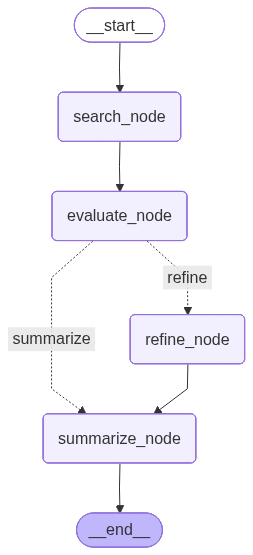

Graph diagram rendered above ↑


In [45]:
try:
    from IPython.display import Image, display
    png_bytes = app.get_graph().draw_mermaid_png()
    display(Image(png_bytes))
    print("Graph diagram rendered above ↑")
except Exception as e:
    print(f"PNG render not available: {e}")
    print("ASCII diagram is shown in the cell above.")

---
######### PART 8 — Run the Graph

We invoke the graph with an initial state — just the query.
Everything else starts as `None` and gets filled in by nodes as they execute.

In [46]:
# ── Run 1: Topic likely to get good results ───────────────────────────────────
print("LANGGRAPH AI NEWS ANALYST")
print("=" * 55)

initial_state = {
    "query"           : "NVIDIA AI chip developments 2025",
    "raw_results"     : None,
    "quality_score"   : None,
    "quality_reason"  : None,
    "refined_results" : None,
    "final_summary"   : None,
    "route_taken"     : None
}

# invoke runs the graph from entry point to END
result = app.invoke(initial_state)

LANGGRAPH AI NEWS ANALYST

🔍 NODE: search_node
   Query: NVIDIA AI chip developments 2025
   Found 9 lines of results
   Preview: 1. NVIDIA Unveils Next-Gen AI Chip 'Orion' at CES 2025 | On January 8, 2025, NVIDIA introduced its latest AI chip, coden...

📊 NODE: evaluate_node
   Quality Score  : 10/10
   Reason         : The results are highly relevant to the query, providing specific details such as names, dates, and numbers, with content from 2025, and covering multiple angles including partnerships, revenue growth, and applications in different sectors.
   Routing decision: ✅ GOOD → summarize

   🔀 ROUTER DECISION: score=10 >= 6 → routing to summarize_node

📝 NODE: summarize_node
   Using: raw results
   Summary generated successfully


In [47]:
# ── Print final summary ───────────────────────────────────────────────────────
print("\n" + "="*55)
print("FINAL OUTPUT")
print("="*55)
print(f"Route taken    : {result['route_taken']}")
print(f"Quality score  : {result['quality_score']}/10")
print(f"Quality reason : {result['quality_reason']}")
print()
print(result["final_summary"])


FINAL OUTPUT
Route taken    : GOOD QUALITY → summarize_node directly
Quality score  : 10/10
Quality reason : The results are highly relevant to the query, providing specific details such as names, dates, and numbers, with content from 2025, and covering multiple angles including partnerships, revenue growth, and applications in different sectors.

## AI News Briefing: NVIDIA AI Chip Developments 2025
**Date:** October 18, 2023

### Key Developments
- **NVIDIA Unveils 'Orion' AI Chip:** On January 8, 2025, NVIDIA introduced its next-generation AI chip, 'Orion', at CES in Las Vegas, boasting a 50% increase in processing power and a 30% reduction in energy consumption compared to the A100.
  
- **Partnership with TSMC for 2nm Production:** NVIDIA announced a strategic partnership with TSMC on February 15, 2025, to produce AI chips using TSMC's advanced 2nm process technology, ensuring cutting-edge manufacturing capabilities.

- **AI Chip Revenue Soars by 40%:** In Q1 2025, NVIDIA's AI ch

In [48]:
# ── Run 2: Try a different topic ──────────────────────────────────────────────
# Change query here and observe if the graph takes a different route
print("RUN 2 — Different topic")
print("=" * 55)

result2 = app.invoke({
    "query"           : "AI regulation and government policy 2025",
    "raw_results"     : None,
    "quality_score"   : None,
    "quality_reason"  : None,
    "refined_results" : None,
    "final_summary"   : None,
    "route_taken"     : None
})

print("\n" + "="*55)
print(f"Route taken   : {result2['route_taken']}")
print(f"Quality score : {result2['quality_score']}/10")
print()
print(result2["final_summary"])

RUN 2 — Different topic

🔍 NODE: search_node
   Query: AI regulation and government policy 2025
   Found 9 lines of results
   Preview: 1. EU Finalizes AI Act with Stricter Compliance Measures | On March 15, 2025, the European Union officially adopted the ...

📊 NODE: evaluate_node
   Quality Score  : 10/10
   Reason         : The results are highly relevant to the query, providing specific names, dates, and details about AI regulation and government policy in 2025, covering multiple regions and angles of AI governance.
   Routing decision: ✅ GOOD → summarize

   🔀 ROUTER DECISION: score=10 >= 6 → routing to summarize_node

📝 NODE: summarize_node
   Using: raw results
   Summary generated successfully

Route taken   : GOOD QUALITY → summarize_node directly
Quality score : 10/10

## AI News Briefing: AI Regulation and Government Policy 2025
**Date:** October 30, 2023

### Key Developments
- **EU Finalizes AI Act:** On March 15, 2025, the European Union adopted the AI Act, imposing stric